#### Imports


In [63]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    mean_squared_error,
    r2_score
)

#### Load Clean Data

In [64]:
df = pd.read_csv("../Data/processed_dataset/emi_cleaned.csv")

df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,...,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38,1,0,3,82600.0,1,0.9,2,2,20000.0,...,1,23700.0,660.0,303200.0,70200.0,3,850000.0,15,2,500.0
1,38,1,0,0,21500.0,1,7.0,1,0,0.0,...,1,4100.0,714.0,92500.0,26900.0,0,128000.0,19,2,700.0
2,38,0,0,3,86100.0,1,5.8,4,1,0.0,...,0,0.0,650.0,672100.0,324200.0,1,306000.0,16,0,27775.0
3,58,1,0,1,66800.0,1,2.2,2,1,0.0,...,0,0.0,685.0,440900.0,178100.0,4,304000.0,83,0,16170.0
4,48,1,0,3,57300.0,1,3.4,2,0,0.0,...,0,0.0,770.0,97300.0,28200.0,2,252000.0,7,2,500.0


#### Split Features and Targets

In [65]:
X = df.drop(['emi_eligibility', 'max_monthly_emi'], axis=1)

y_class = df['emi_eligibility']
y_reg = df['max_monthly_emi']

#### Train-Test Split

In [66]:
X_train, X_test, y_train_class, y_test_class, y_train_reg, y_test_reg = train_test_split(
    X, y_class, y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

# Classification Models

## Logistic Regression

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train_class)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression:\n")
print(classification_report(y_test_class, y_pred_log))

Logistic Regression:

              precision    recall  f1-score   support

           0       0.81      0.73      0.77     14889
           1       0.14      0.65      0.23      3497
           2       0.98      0.80      0.88     62574

    accuracy                           0.78     80960
   macro avg       0.64      0.73      0.63     80960
weighted avg       0.91      0.78      0.83     80960



## Random Forest Classifier

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train_class)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest:\n")
print(classification_report(y_test_class, y_pred_rf))

Random Forest:

              precision    recall  f1-score   support

           0       0.90      0.86      0.88     14889
           1       0.85      0.02      0.03      3497
           2       0.93      0.99      0.96     62574

    accuracy                           0.92     80960
   macro avg       0.89      0.62      0.62     80960
weighted avg       0.92      0.92      0.90     80960



## XGBoost Classifier

In [69]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train, y_train_class)

y_pred_xgb = xgb_clf.predict(X_test)

# Test model directly (bypass Streamlit)


print("XGBoost:\n")
print(classification_report(y_test_class, y_pred_xgb))

XGBoost:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94     14889
           1       0.72      0.07      0.13      3497
           2       0.96      1.00      0.98     62574

    accuracy                           0.95     80960
   macro avg       0.86      0.68      0.68     80960
weighted avg       0.94      0.95      0.93     80960



In [70]:
print(df['emi_eligibility'].value_counts())

le = LabelEncoder()
le.fit(df['emi_eligibility'])
print(le.classes_)

emi_eligibility
2    312868
0     74444
1     17488
Name: count, dtype: int64
[0 1 2]


# Regression Models

In [71]:
assert 'emi_eligibility' not in X.columns

## Linear Regression

In [72]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train_reg)

y_pred_lr = lr_model.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test_reg, y_pred_lr))
r2_lr = r2_score(y_test_reg, y_pred_lr)

print("Linear Regression:")
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression:
RMSE: 4178.309254997966
R2: 0.7109951835089218


## Random Forest Regressor

In [73]:
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_reg.fit(X_train, y_train_reg)

y_pred_rf_reg = rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg))
r2_rf = r2_score(y_test_reg, y_pred_rf_reg)

print("\nRandom Forest Regressor:")
print("RMSE:", rmse_rf)
print("R2:", r2_rf)


Random Forest Regressor:
RMSE: 1383.3008110275075
R2: 0.9683235005428789


## XGBoost Regressor

In [74]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_reg.fit(X_train, y_train_reg)

y_pred_xgb_reg = xgb_reg.predict(X_test)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
r2_xgb = r2_score(y_test_reg, y_pred_xgb_reg)

print("\nXGBoost Regressor:")
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)


XGBoost Regressor:
RMSE: 1037.4668455290177
R2: 0.9821822700439239


In [75]:
print("\n--- Final Regression Comparison ---")

print(f"Linear RMSE: {rmse_lr}")
print(f"RF RMSE: {rmse_rf}")
print(f"XGB RMSE: {rmse_xgb}")

print(f"\nLinear R2: {r2_lr}")
print(f"RF R2: {r2_rf}")
print(f"XGB R2: {r2_xgb}")


--- Final Regression Comparison ---
Linear RMSE: 4178.309254997966
RF RMSE: 1383.3008110275075
XGB RMSE: 1037.4668455290177

Linear R2: 0.7109951835089218
RF R2: 0.9683235005428789
XGB R2: 0.9821822700439239


###
Model Comparison Summary:

1. Linear Regression performed poorly due to inability to capture non-linear financial relationships.

2. Random Forest showed strong performance with significant reduction in RMSE and high R².

3. XGBoost achieved the best performance:
   - Lowest RMSE (~1037)
   - Highest R² (~0.982)

Conclusion:
XGBoost Regressor is selected as the final model for maximum EMI prediction due to superior accuracy and robustness.


In [76]:
import joblib

joblib.dump(xgb_clf, "xgb_classifier.pkl")
joblib.dump(xgb_reg, "xgb_regressor.pkl")

['xgb_regressor.pkl']

In [77]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_class)

xgb_clf.fit(X_train_smote, y_train_smote)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


# MLFlow Setup

In [78]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("EMI_Prediction_Project")

<Experiment: artifact_location='file:///e:/Data_Science/Guvi_Capstone%20Project/EMI_Predict_financial%20Risk%20Assessment/notebooks/mlruns/962091367227442449', creation_time=1776337026313, experiment_id='962091367227442449', last_update_time=1776337026313, lifecycle_stage='active', name='EMI_Prediction_Project', tags={}, trace_location=None, workspace='default'>

## Log Classification Model

In [79]:
import mlflow
import mlflow.sklearn

# 🔥 THIS LINE FIXES YOUR ERROR
mlflow.set_experiment("EMI_Prediction_Project")

with mlflow.start_run(run_name="XGBoost_Classifier"):

    xgb_clf.fit(X_train, y_train_class)
    y_pred = xgb_clf.predict(X_test)

    from sklearn.metrics import accuracy_score

    acc = accuracy_score(y_test_class, y_pred)

    mlflow.log_metric("accuracy", acc)
    mlflow.sklearn.log_model(xgb_clf, "classifier_model")

    

2026/04/17 09:33:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:33:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## Log Regression Model

In [80]:
with mlflow.start_run(run_name="XGBoost_Regressor"):

    xgb_reg.fit(X_train, y_train_reg)
    y_pred = xgb_reg.predict(X_test)

    from sklearn.metrics import mean_squared_error
    import numpy as np

    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))

    mlflow.log_metric("rmse", rmse)

    mlflow.sklearn.log_model(xgb_reg, "model")

2026/04/17 09:33:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 09:33:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [81]:
joblib.dump(xgb_clf, "../models/xgb_classifier.pkl")
joblib.dump(xgb_reg, "../models/xgb_regressor.pkl")

['../models/xgb_regressor.pkl']

In [82]:
joblib.dump(X.columns, "../models/feature_columns.pkl")


['../models/feature_columns.pkl']

#### Apply SMOTE

In [83]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train_class)

#### Retrain XGBoost

In [84]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss'
)

xgb_clf.fit(X_train_smote, y_train_smote)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


#### Evaluate Again

In [85]:
from sklearn.metrics import classification_report

y_pred = xgb_clf.predict(X_test)

print(classification_report(y_test_class, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91     14889
           1       0.32      0.34      0.33      3497
           2       0.97      0.96      0.97     62574

    accuracy                           0.93     80960
   macro avg       0.73      0.74      0.74     80960
weighted avg       0.93      0.93      0.93     80960



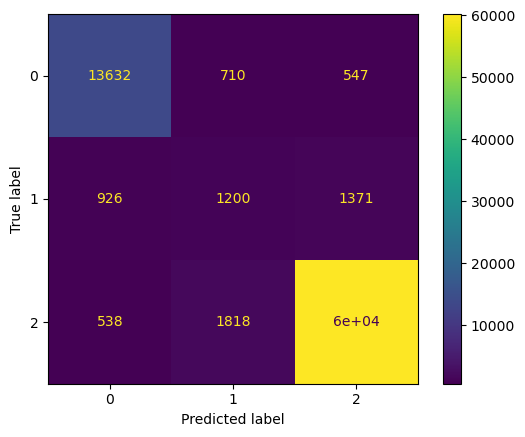

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(xgb_clf, X_test, y_test_class)